✅ LA County border loaded.
✅ Full geographic data loaded with 38878 properties.


C:\Users\kaiso\AppData\Local\Temp\ipykernel_33768\3503308755.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_ranks))


✅ Set plot bounds to: (-13236804.73, 3940526.32, -13096976.87, 4138905.66)


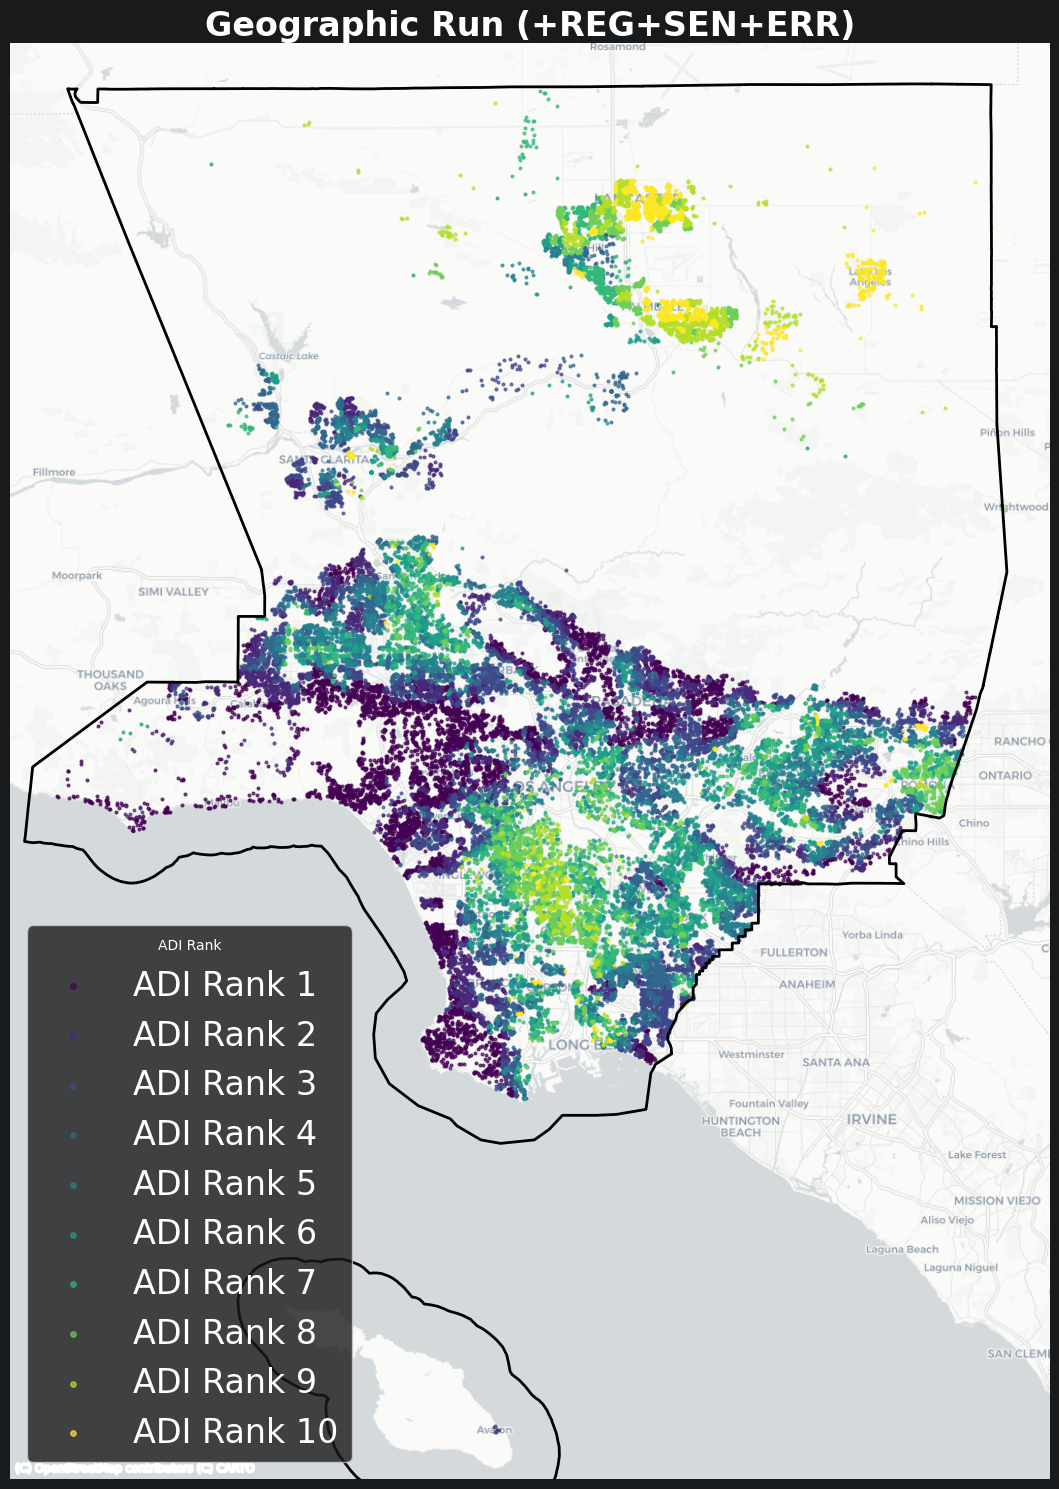

In [7]:
# =================================================
# 1. IMPORTS & SETUP
# =================================================
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx

# =================================================
# 2. CONFIGURATION
# =================================================
DATA_DIR = r"C:\Users\kaiso\PycharmProjects\BPAI\clustering_results\Results_Unweighted\s42_Unweighted_Baseline"
FULL_DATA_FILENAME = "+REG+SEN+ERR_full_data.csv"
CENSUS_SHAPEFILE_PATH = r"C:\Users\kaiso\PycharmProjects\BPAI\Data\shapefile_2015_BlockGroup_Calif\tl_2015_06_bg.shp"

full_data_path = os.path.join(DATA_DIR, FULL_DATA_FILENAME)

# =================================================
# 3. DATA LOADING & PREPARATION
# =================================================
try:
    census_gdf = gpd.read_file(CENSUS_SHAPEFILE_PATH)
    la_census_gdf = census_gdf[census_gdf['COUNTYFP'] == '037']
    la_border = la_census_gdf.dissolve().to_crs(epsg=3857)
    print("✅ LA County border loaded.")
except Exception as e:
    print(f"❌ Could not load shapefile: {e}")
    la_border = None

if os.path.exists(full_data_path):
    df_full = pd.read_csv(full_data_path)
    gdf = gpd.GeoDataFrame(
        df_full,
        geometry=gpd.points_from_xy(df_full.longitude, df_full.latitude),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)
    print(f"✅ Full geographic data loaded with {len(df_full)} properties.")
else:
    gdf = None
    print(f"❌ CRITICAL: Full data not found at {full_data_path}")

# =================================================
# 4. PLOTTING
# =================================================
if gdf is not None and not gdf.empty:
    fig, ax = plt.subplots(1, 1, figsize=(15, 15))

    # Use a categorical colormap
    unique_ranks = sorted(gdf['ADI_STATERNK'].unique())
    colors = plt.cm.get_cmap('viridis', len(unique_ranks))
    color_map = {rank: colors(i) for i, rank in enumerate(unique_ranks)}

    for rank, color in color_map.items():
        gdf[gdf['ADI_STATERNK'] == rank].plot(ax=ax, color=color, marker='.', markersize=15, alpha=0.7, label=f'ADI Rank {rank}')

    if la_border is not None:
        la_border.plot(ax=ax, color='none', edgecolor='black', linewidth=2)

    try:
        minx, miny, maxx, maxy = gdf.total_bounds
        buffer = (maxx - minx) * 0.05
        ax.set_xlim(minx - buffer, maxx + buffer)
        ax.set_ylim(miny - buffer, maxy + buffer)
        print(f"✅ Set plot bounds to: ({minx:.2f}, {miny:.2f}, {maxx:.2f}, {maxy:.2f})")
    except Exception as e:
        print(f"❌ Could not set plot bounds: {e}")

    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)

    ax.set_title('Geographic Run (+REG+SEN+ERR)', fontsize=24, fontweight='bold')
    ax.axis('off')
    ax.legend(title="ADI Rank", markerscale=2, fontsize=24)

    plt.tight_layout()
    plt.savefig('geographic_run_map.pdf', format='pdf', bbox_inches='tight')
    plt.show()

else:
    print("Could not generate plot because data was not loaded.")
